# Mean vs Harmonic Mean — A 3D Visual Exploration

This notebook uses **3D plots** to build an intuitive understanding of:
- The **Arithmetic Mean** (standard average)
- The **Harmonic Mean** (reciprocal average)

By exploring how each mean responds to changing inputs across a surface, we'll see *why* the harmonic mean is essential in specific contexts.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from scipy.stats import hmean
from paths import root

# Use a clean, readable style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

print("Libraries loaded. Let's explore means! 🎲")

Libraries loaded. Let's explore means! 🎲


---
## 📐 1. Definitions

For two positive values **a** and **b**:

$$\text{Arithmetic Mean} = \frac{a + b}{2}$$

$$\text{Harmonic Mean} = \frac{2}{\dfrac{1}{a} + \dfrac{1}{b}} = \frac{2ab}{a+b}$$

> **Key insight:** The harmonic mean is the reciprocal of the arithmetic mean of the reciprocals. It gives more weight to **smaller values**.

It always holds that: **Harmonic Mean ≤ Arithmetic Mean** (AM-HM inequality)

---
## 📊 2. Plot 1 — The Two Surfaces Side by Side

We plot both means as 3D surfaces over a grid of (a, b) inputs.  
Where the surfaces *differ* most is where the harmonic mean matters most.

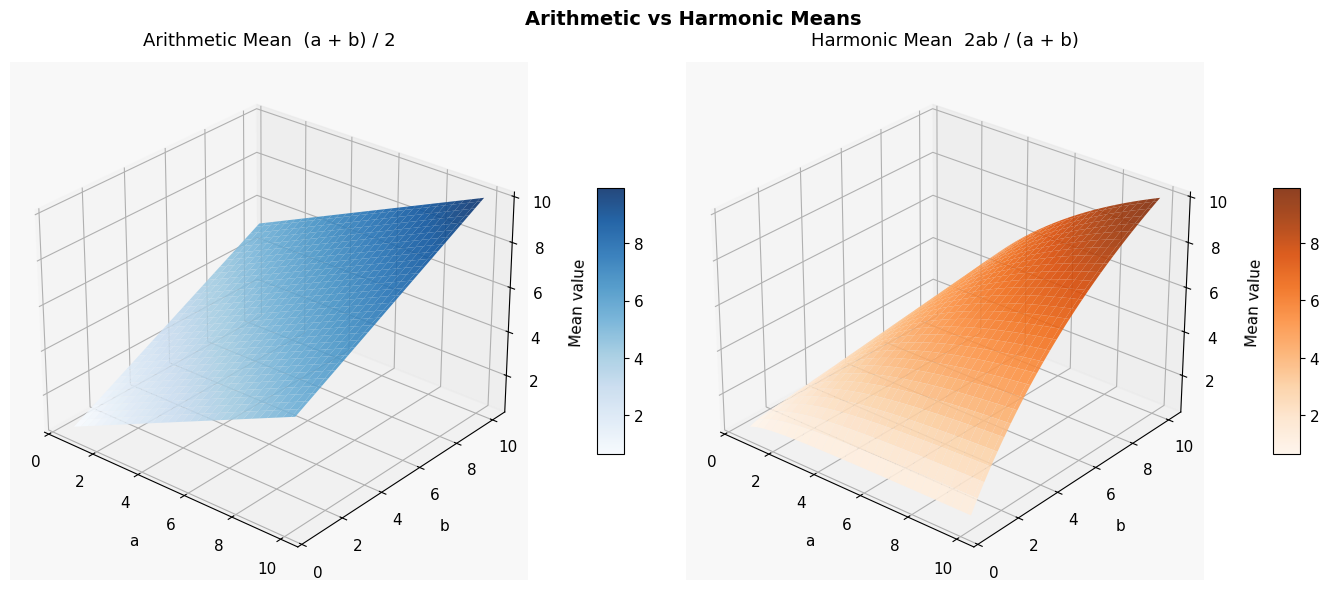

In [ ]:
# Create grid of values for a and b
vals = np.linspace(0.5, 10, 60)
A, B = np.meshgrid(vals, vals)

# Compute both means across the grid
arith_mean = (A + B) / 2
harm_mean  = (2 * A * B) / (A + B)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': '3d'})

for ax, Z, title, cmap in zip(
    axes,
    [arith_mean, harm_mean],
    ['Arithmetic Mean  (a + b) / 2', 'Harmonic Mean  2ab / (a + b)'],
    [cm.Blues, cm.Oranges]
):
    surf = ax.plot_surface(A, B, Z, cmap=cmap, alpha=0.88, linewidth=0)
    ax.set_xlabel('a', labelpad=8)
    ax.set_ylabel('b', labelpad=8)
    ax.set_zlabel('Mean value', labelpad=8)
    ax.set_title(title, pad=12)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1)
    ax.view_init(elev=28, azim=-50)

fig.suptitle('Arithmetic vs Harmonic Means',
             fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
plt.savefig(f'{root}/fig/mean_comparison.png', dpi=300)
plt.show()

> **Observation:** Both surfaces rise similarly when a and b are large. But look near the axes — when one value is small (e.g. a=0.5, b=10), the harmonic mean stays much lower than the arithmetic mean. It's being "pulled down" by the small value.

---
## 🔍 3. Plot 2 — The Difference Surface

Subtracting the harmonic from the arithmetic mean reveals *where* and *how much* they diverge.

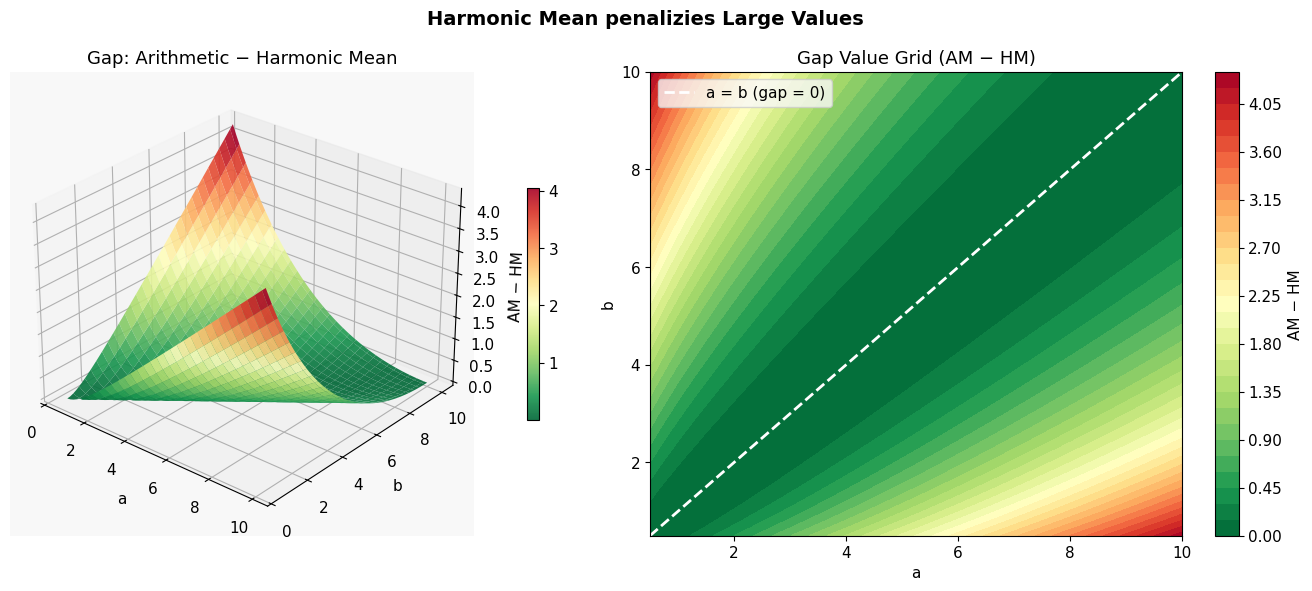

In [17]:
difference = arith_mean - harm_mean   # always ≥ 0

fig = plt.figure(figsize=(14, 6))

# --- 3D surface of the gap ---
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(A, B, difference, cmap=cm.RdYlGn_r, alpha=0.9, linewidth=0)
ax1.set_xlabel('a')
ax1.set_ylabel('b')
ax1.set_zlabel('AM − HM')
ax1.set_title('Gap: Arithmetic − Harmonic Mean')
ax1.view_init(elev=28, azim=-50)
fig.colorbar(surf, ax=ax1, shrink=0.5, pad=0.08, location='right')

# --- Top-down heatmap of the gap ---
ax2 = fig.add_subplot(122)
contour = ax2.contourf(A, B, difference, levels=30, cmap=cm.RdYlGn_r)
ax2.set_xlabel('a')
ax2.set_ylabel('b')
ax2.set_title('Gap Value Grid (AM − HM)')
fig.colorbar(contour, ax=ax2, label='AM − HM')

# Mark the diagonal (a == b) where gap is 0
diag = np.linspace(0.5, 10, 100)
ax2.plot(diag, diag, 'w--', linewidth=2, label='a = b (gap = 0)')
ax2.legend(loc='upper left')

fig.suptitle('Harmonic Mean penalizies Large Values', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{root}/fig/mean_gap.png', dpi=300)
plt.show()

> **Key insight:** The gap is **zero when a = b** (the white dashed diagonal). The larger the *ratio* between a and b, the bigger the difference — confirming that the harmonic mean resists extreme values more strongly.

---
## 🚗 4. Plot 3 — The Classic Real-World Example: Average Speed

> You drive from A→B at speed **s₁**, then B→A at speed **s₂**, covering the same distance each way.  
> What is your **average speed** for the round trip?

$$\text{Correct average speed} = \text{Harmonic Mean}(s_1, s_2) = \frac{2 s_1 s_2}{s_1 + s_2}$$

The arithmetic mean gives the **wrong answer** here, because you spend more *time* at the slower speed.

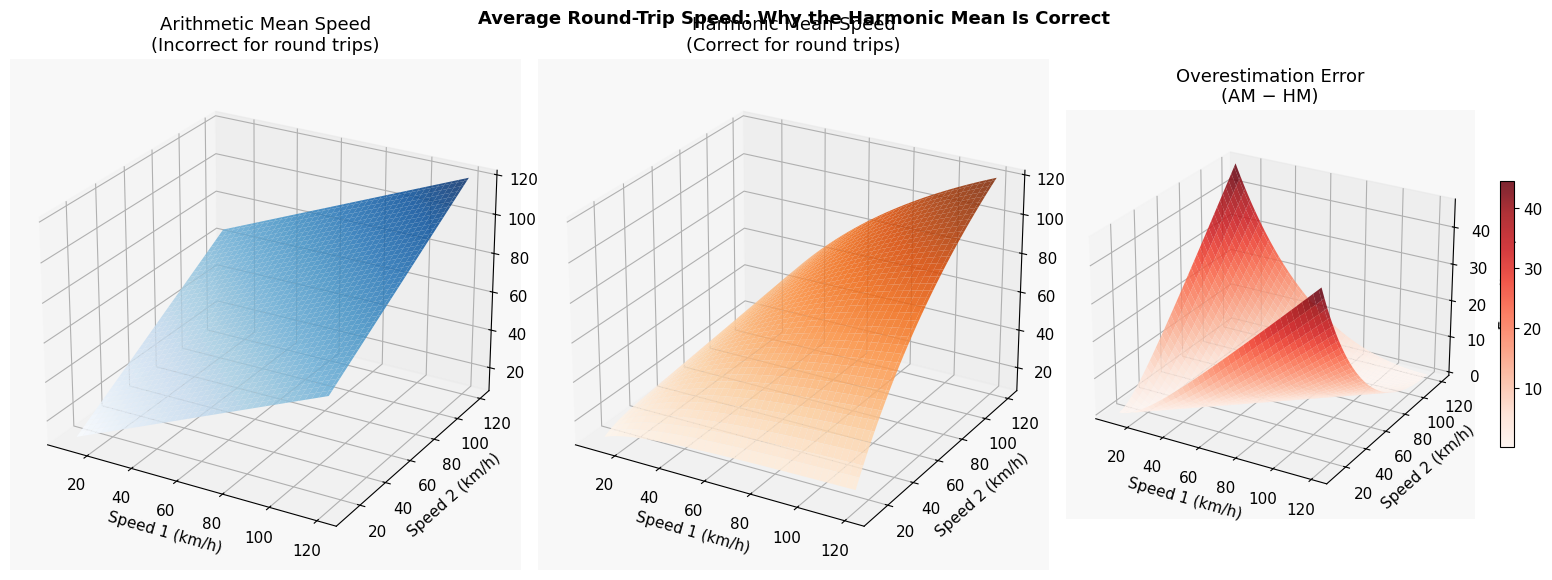

Example: Go at 60 km/h, return at 120 km/h
  Arithmetic mean: 90.0 km/h  ← WRONG
  Harmonic mean:   80.0 km/h  ← CORRECT


In [4]:
speeds = np.linspace(10, 120, 80)
S1, S2 = np.meshgrid(speeds, speeds)

am_speed = (S1 + S2) / 2
hm_speed = (2 * S1 * S2) / (S1 + S2)
speed_error = am_speed - hm_speed   # how wrong AM is

fig = plt.figure(figsize=(16, 6))

# --- Arithmetic Mean surface ---
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(S1, S2, am_speed, cmap=cm.Blues, alpha=0.85, linewidth=0)
ax1.set_xlabel('Speed 1 (km/h)')
ax1.set_ylabel('Speed 2 (km/h)')
ax1.set_zlabel('Average speed')
ax1.set_title('Arithmetic Mean Speed\n(Incorrect for round trips)')
ax1.view_init(elev=25, azim=-60)

# --- Harmonic Mean surface ---
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(S1, S2, hm_speed, cmap=cm.Oranges, alpha=0.85, linewidth=0)
ax2.set_xlabel('Speed 1 (km/h)')
ax2.set_ylabel('Speed 2 (km/h)')
ax2.set_zlabel('Average speed')
ax2.set_title('Harmonic Mean Speed\n(Correct for round trips)')
ax2.view_init(elev=25, azim=-60)

# --- Error surface ---
ax3 = fig.add_subplot(133, projection='3d')
surf = ax3.plot_surface(S1, S2, speed_error, cmap=cm.Reds, alpha=0.85, linewidth=0)
ax3.set_xlabel('Speed 1 (km/h)')
ax3.set_ylabel('Speed 2 (km/h)')
ax3.set_zlabel('Error (km/h)')
ax3.set_title('Overestimation Error\n(AM − HM)')
ax3.view_init(elev=25, azim=-60)
fig.colorbar(surf, ax=ax3, shrink=0.5)

fig.suptitle('Average Round-Trip Speed: Why the Harmonic Mean Is Correct',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Numerical example
s1, s2 = 60, 120
print(f"Example: Go at {s1} km/h, return at {s2} km/h")
print(f"  Arithmetic mean: {(s1+s2)/2:.1f} km/h  ← WRONG")
print(f"  Harmonic mean:   {2*s1*s2/(s1+s2):.1f} km/h  ← CORRECT")

---
## 🎯 5. Plot 4 — AM-HM Inequality Visualised in 3D

The AM-HM inequality states: for any positive a, b:

$$HM \leq AM$$

with equality **only** when a = b.  

Let's see both surfaces together, and the "gap curtain" between them.

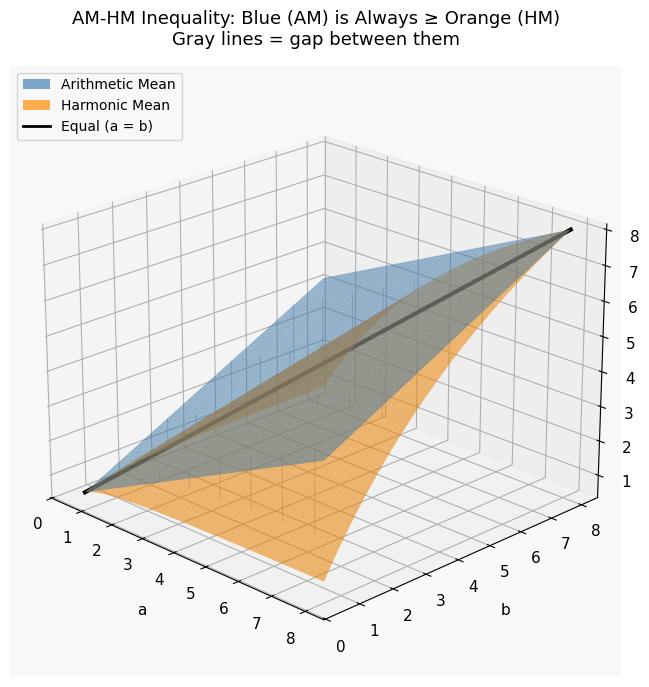

In [5]:
vals2 = np.linspace(0.5, 8, 50)
A2, B2 = np.meshgrid(vals2, vals2)

am2 = (A2 + B2) / 2
hm2 = (2 * A2 * B2) / (A2 + B2)

fig = plt.figure(figsize=(13, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot Arithmetic Mean surface (blue, higher)
surf_am = ax.plot_surface(A2, B2, am2,
                          color='steelblue', alpha=0.55,
                          linewidth=0, label='Arithmetic Mean')

# Plot Harmonic Mean surface (orange, lower)
surf_hm = ax.plot_surface(A2, B2, hm2,
                          color='darkorange', alpha=0.55,
                          linewidth=0, label='Harmonic Mean')

# Draw the a = b diagonal where both means meet
diag_vals = np.linspace(0.5, 8, 100)
diag_mean = diag_vals   # when a == b, AM == HM == a
ax.plot(diag_vals, diag_vals, diag_mean,
        'k-', linewidth=3, label='AM = HM  (when a = b)')

# Draw a few "curtain" lines to show the gap at fixed b values
for b_fixed in [1, 3, 5, 7]:
    a_line = np.linspace(0.5, 8, 40)
    am_line = (a_line + b_fixed) / 2
    hm_line = (2 * a_line * b_fixed) / (a_line + b_fixed)
    for aa, amv, hmv in zip(a_line[::5], am_line[::5], hm_line[::5]):
        ax.plot([aa, aa], [b_fixed, b_fixed], [hmv, amv],
                'gray', alpha=0.4, linewidth=0.8)

ax.set_xlabel('a', labelpad=10)
ax.set_ylabel('b', labelpad=10)
ax.set_zlabel('Mean value', labelpad=10)
ax.set_title('AM-HM Inequality: Blue (AM) is Always ≥ Orange (HM)\nGray lines = gap between them',
             pad=15)
ax.view_init(elev=22, azim=-45)

# Manual legend patches
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor='steelblue', alpha=0.7, label='Arithmetic Mean'),
    Patch(facecolor='darkorange', alpha=0.7, label='Harmonic Mean'),
    Line2D([0], [0], color='black', linewidth=2, label='Equal (a = b)'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

---
## 📈 6. Plot 5 — Sensitivity to Small Values (3D Slice Exploration)

Fix **b = 5** and watch how each mean responds as **a** varies from near-zero to 20.  
Then do the same on a 2D+3D combined view.

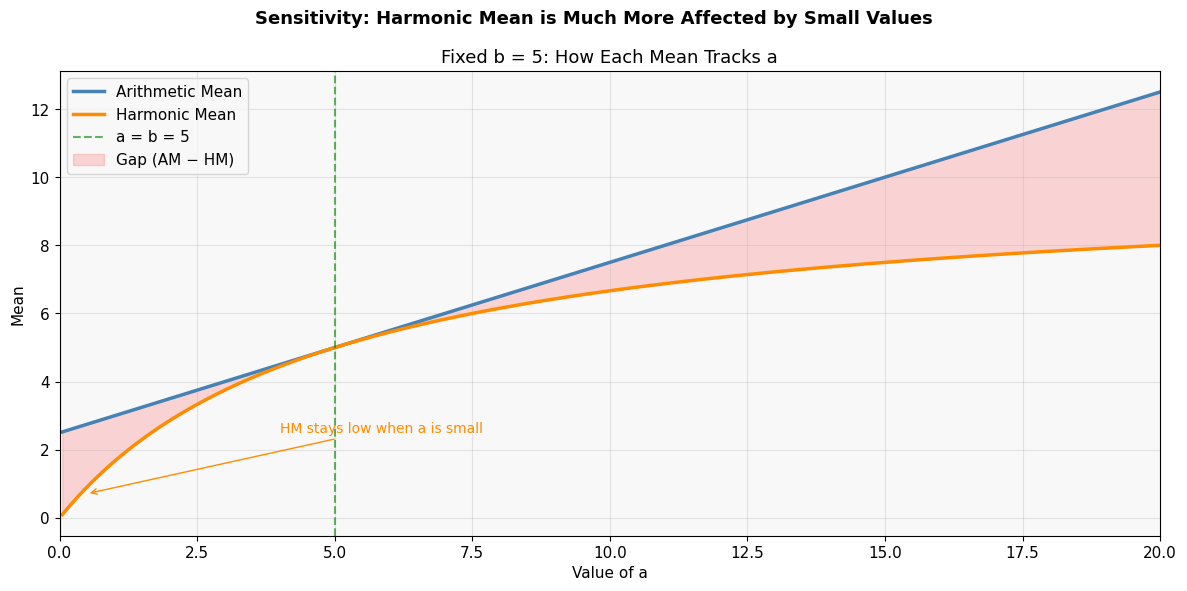

In [20]:
a_vals = np.linspace(0.05, 20, 300)
b_fixed_values = [1, 5, 10]

fig, ax = plt.subplots(figsize=(12, 6))

# --- 2D line plot for b=5 ---
b = 5
am_vals = (a_vals + b) / 2
hm_vals = (2 * a_vals * b) / (a_vals + b)

ax.plot(a_vals, am_vals, 'steelblue', linewidth=2.5, label='Arithmetic Mean')
ax.plot(a_vals, hm_vals, 'darkorange', linewidth=2.5, label='Harmonic Mean')
ax.axvline(x=b, color='green', linestyle='--', alpha=0.6, label=f'a = b = {b}')
ax.fill_between(a_vals, hm_vals, am_vals, alpha=0.15, color='red', label='Gap (AM − HM)')
ax.set_xlabel('Value of a')
ax.set_ylabel('Mean')
ax.set_title(f'Fixed b = {b}: How Each Mean Tracks a')
ax.legend()
ax.set_xlim([0, 20])
ax.grid(True, alpha=0.3)

# Annotate key region
ax.annotate('HM stays low when a is small',
            xy=(0.5, hm_vals[5]), xytext=(4, 2.5),
            arrowprops=dict(arrowstyle='->', color='darkorange'),
            color='darkorange', fontsize=10)

fig.suptitle('Sensitivity: Harmonic Mean is Much More Affected by Small Values',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{root}/fig/mean_sensitivity.png', dpi=300)
plt.show()

---
## 🧩 7. Summary Table & When to Use Each

| Property | Arithmetic Mean | Harmonic Mean |
|---|---|---|
| **Formula (2 values)** | (a + b) / 2 | 2ab / (a + b) |
| **Sensitive to large values?** | Yes (pulled up) | Less so |
| **Sensitive to small values?** | Less so | Yes (pulled down) |
| **AM ≥ HM always?** | ✅ Yes | — |
| **Equal when…** | a = b | a = b |
| **Use for…** | Temperatures, heights, test scores | Speeds, rates, P/E ratios, F1-score |

### 🏁 Rule of Thumb

> Use the **harmonic mean** when you're averaging **rates** (speed, price-per-unit, frequency) — i.e., quantities expressed as *X per Y*. Use the **arithmetic mean** for direct measurements.

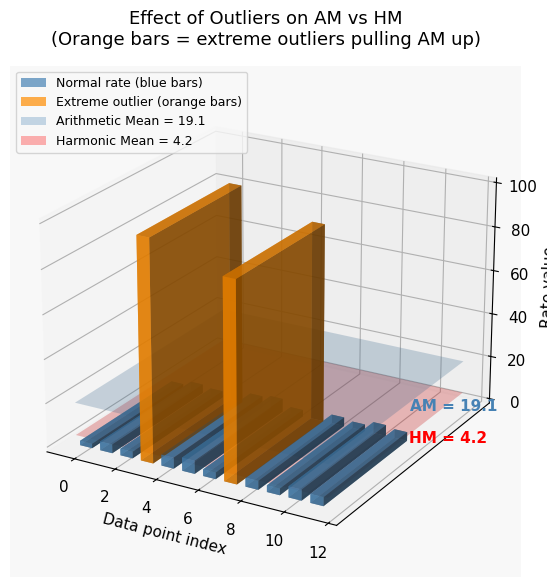


Arithmetic Mean = 19.08  (badly skewed by the two large outliers)
Harmonic Mean   = 4.23  (much more representative of the typical rate)


In [7]:
# Final demo: N-value harmonic vs arithmetic mean
np.random.seed(42)

fig = plt.figure(figsize=(14, 6))

# Generate some skewed rate data
n_points = 12
rates = np.array([2, 4, 3, 100, 5, 6, 3, 90, 4, 3, 5, 4], dtype=float)  # mix of normal and extreme rates

am = np.mean(rates)
hm = len(rates) / np.sum(1.0 / rates)

# 3D bar chart showing each rate and the two means
ax = fig.add_subplot(111, projection='3d')

x_pos = np.arange(n_points)
y_pos = np.zeros(n_points)
z_pos = np.zeros(n_points)
dx = dy = 0.6
dz = rates

# Color bars by height to highlight outliers
colors = ['darkorange' if r > 20 else 'steelblue' for r in rates]
ax.bar3d(x_pos - dx/2, y_pos, z_pos, dx, dy, dz, color=colors, alpha=0.7, shade=True)

# Draw AM and HM horizontal planes
x_plane = [-0.5, n_points - 0.5]
y_plane = [0, 1]
Xp, Yp = np.meshgrid(x_plane, y_plane)

ax.plot_surface(Xp, Yp, np.full_like(Xp, am),
                color='steelblue', alpha=0.25)
ax.plot_surface(Xp, Yp, np.full_like(Xp, hm),
                color='red', alpha=0.25)

# Labels
ax.text(n_points, 0.5, am + 1, f'AM = {am:.1f}', color='steelblue', fontsize=11, fontweight='bold')
ax.text(n_points, 0.5, hm + 1, f'HM = {hm:.1f}', color='red', fontsize=11, fontweight='bold')

ax.set_xlabel('Data point index')
ax.set_ylabel('')
ax.set_zlabel('Rate value')
ax.set_title('Effect of Outliers on AM vs HM\n(Orange bars = extreme outliers pulling AM up)', pad=15)
ax.view_init(elev=22, azim=-60)
ax.set_yticks([])

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', alpha=0.7, label=f'Normal rate (blue bars)'),
    Patch(facecolor='darkorange', alpha=0.7, label='Extreme outlier (orange bars)'),
    Patch(facecolor='steelblue', alpha=0.3, label=f'Arithmetic Mean = {am:.1f}'),
    Patch(facecolor='red', alpha=0.3, label=f'Harmonic Mean = {hm:.1f}'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nArithmetic Mean = {am:.2f}  (badly skewed by the two large outliers)")
print(f"Harmonic Mean   = {hm:.2f}  (much more representative of the typical rate)")

---
## ✅ Conclusion

Through these 3D plots we've seen:

1. **Both means rise** with increasing values — but they diverge when values are unequal.
2. **The gap is zero only when a = b** — the AM-HM diagonal of equality.
3. **Harmonic mean is pulled down by small values** — making it robust for rates.
4. **For round-trip speeds**, the harmonic mean gives the correct answer.
5. **Outliers inflate the arithmetic mean far more** than the harmonic mean.

> 💡 *Think of the harmonic mean as "pessimistic" — it respects the bottleneck.*